In [3]:
# imports
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import json

plt.rcParams['figure.figsize'] = (14,4)

In [4]:
# loading file and inspecting
df = pd.read_csv('../data/NAB/data/realKnownCause/machine_temperature_system_failure.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

print(df.shape)
print(df.head)
print(df.describe())

(22695, 1)
<bound method NDFrame.head of                          value
timestamp                     
2013-12-02 21:15:00  73.967322
2013-12-02 21:20:00  74.935882
2013-12-02 21:25:00  76.124162
2013-12-02 21:30:00  78.140707
2013-12-02 21:35:00  79.329836
...                        ...
2014-02-19 15:05:00  98.185415
2014-02-19 15:10:00  97.804168
2014-02-19 15:15:00  97.135468
2014-02-19 15:20:00  98.056852
2014-02-19 15:25:00  96.903861

[22695 rows x 1 columns]>
              value
count  22695.000000
mean      85.926498
std       13.746912
min        2.084721
25%       83.080078
50%       89.408246
75%       94.016252
max      108.510543


In [5]:
# load the anomalies

with open('../data/NAB/labels/combined_windows.json') as f:
    labels = json.load(f)

# view anomaly windows
key = 'realKnownCause/machine_temperature_system_failure.csv'
print(labels[key])

[['2013-12-10 06:25:00.000000', '2013-12-12 05:35:00.000000'], ['2013-12-15 17:50:00.000000', '2013-12-17 17:00:00.000000'], ['2014-01-27 14:20:00.000000', '2014-01-29 13:30:00.000000'], ['2014-02-07 14:55:00.000000', '2014-02-09 14:05:00.000000']]


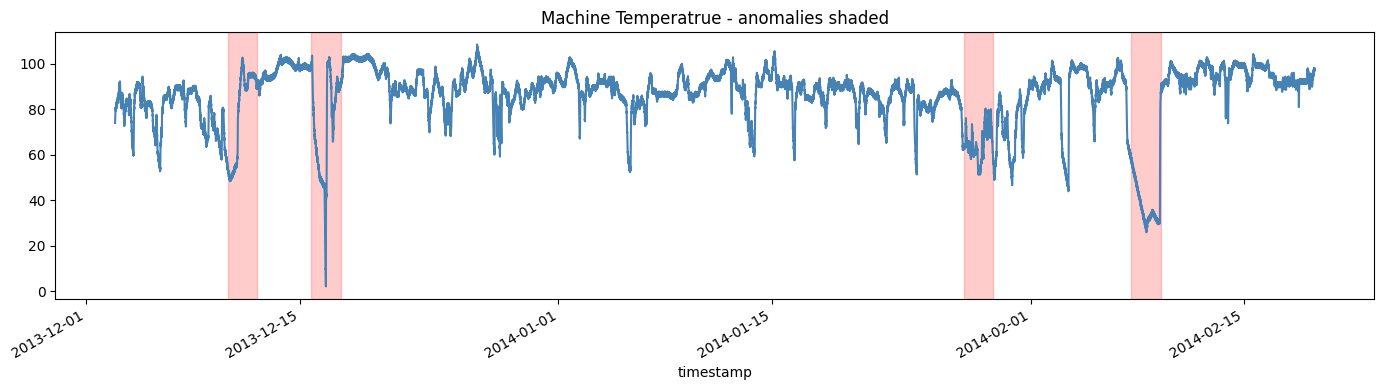

In [6]:
# plot time series with anomaly windows shaded
fig, ax = plt.subplots()
df['value'].plot(ax=ax, title='Machine Temperatrue - anomalies shaded', color='steelblue')

for window in labels[key]:
    ax.axvspan(window[0], window[1], color='red', alpha=0.2)

plt.tight_layout()
plt.show()     

In [7]:
# identify missing values and look at data values 
print("Missing values:", df['value'].isnull().sum())
print("Duplicate timestamps:", df.index.duplicated().sum())
print("Sampling interval:", df.index[1] - df.index[0])
print("Total time span:", df.index[-1] - df.index[0])

Missing values: 0
Duplicate timestamps: 12
Sampling interval: 0 days 00:05:00
Total time span: 78 days 18:10:00


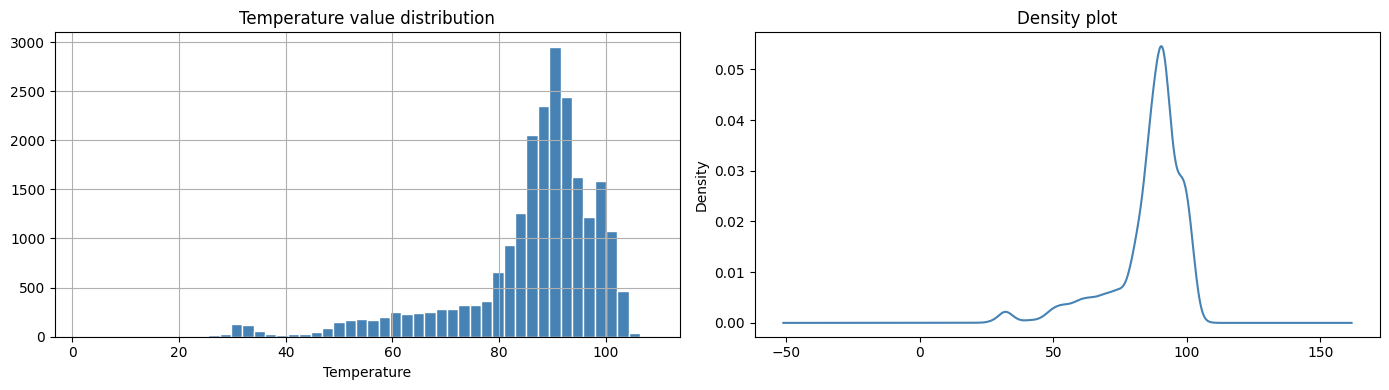

In [8]:
# feature distibution 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['value'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Temperature value distribution')
axes[0].set_xlabel('Temperature')

df['value'].plot(kind='kde', ax=axes[1], color='steelblue')
axes[1].set_title('Density plot')

plt.tight_layout()
plt.show()

In [9]:
# ground truth anomly label column, going to use to evalute models later
df['is_anomaly'] = 0

for window in labels[key]:
    df.loc[window[0]:window[1], 'is_anomaly'] = 1

print("Normal points:  ", (df['is_anomaly'] == 0).sum())
print("Anomaly points: ", (df['is_anomaly'] == 1).sum())
print("Anomaly rate:   ", f"{df['is_anomaly'].mean():.2%}")

Normal points:   20427
Anomaly points:  2268
Anomaly rate:    9.99%


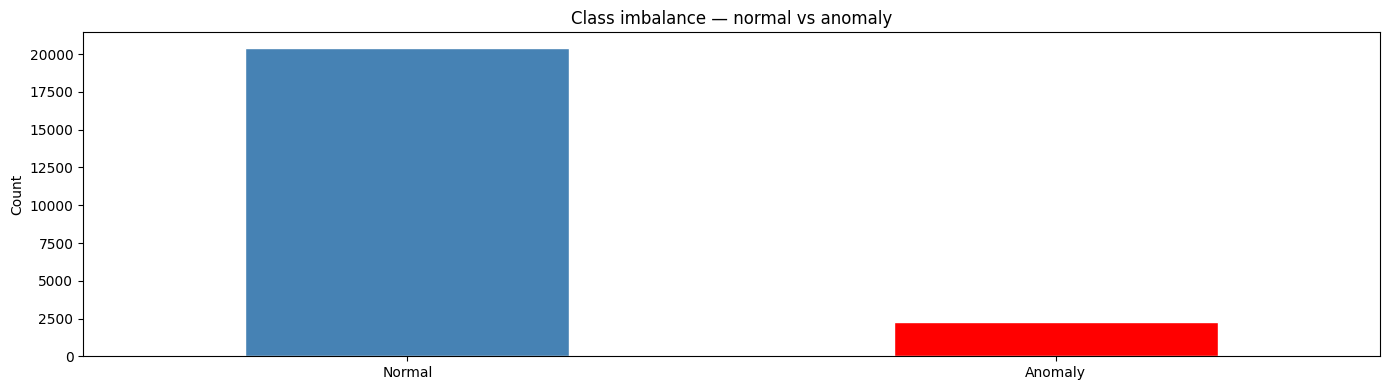

In [10]:
# class imbalance bar chart
counts = df['is_anomaly'].value_counts()
counts.index = ['Normal', 'Anomaly']
counts.plot(kind='bar', color=['steelblue', 'red'], edgecolor='white')
plt.title('Class imbalance — normal vs anomaly')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [11]:
# feature engineering, the features models will train on 
df['rolling_mean'] = df['value'].rolling(window=12).mean()   # 1hr rolling avg
df['rolling_std']  = df['value'].rolling(window=12).std()    # 1hr rolling volatility
df['lag_1']        = df['value'].shift(1)                    # value 5 mins ago
df['lag_12']       = df['value'].shift(12)                   # value 1hr ago
df['rate_of_change'] = df['value'].diff()                    # how fast it's changing

# drop rows with NaN created by rolling
df.dropna(inplace=True)

print("Dataset shape after feature engineering:", df.shape)
print(df.head())

Dataset shape after feature engineering: (22683, 7)
                         value  is_anomaly  rolling_mean  rolling_std  \
timestamp                                                               
2013-12-02 22:15:00  79.302033           0     78.934753     1.770924   
2013-12-02 22:20:00  80.802624           0     79.423648     1.318664   
2013-12-02 22:25:00  80.377789           0     79.778117     0.833592   
2013-12-02 22:30:00  80.479237           0     79.972994     0.674089   
2013-12-02 22:35:00  81.423560           0     80.147471     0.758200   

                         lag_1     lag_12  rate_of_change  
timestamp                                                  
2013-12-02 22:15:00  79.508159  73.967322       -0.206126  
2013-12-02 22:20:00  79.302033  74.935882        1.500591  
2013-12-02 22:25:00  80.802624  76.124162       -0.424835  
2013-12-02 22:30:00  80.377789  78.140707        0.101448  
2013-12-02 22:35:00  80.479237  79.329836        0.944323  


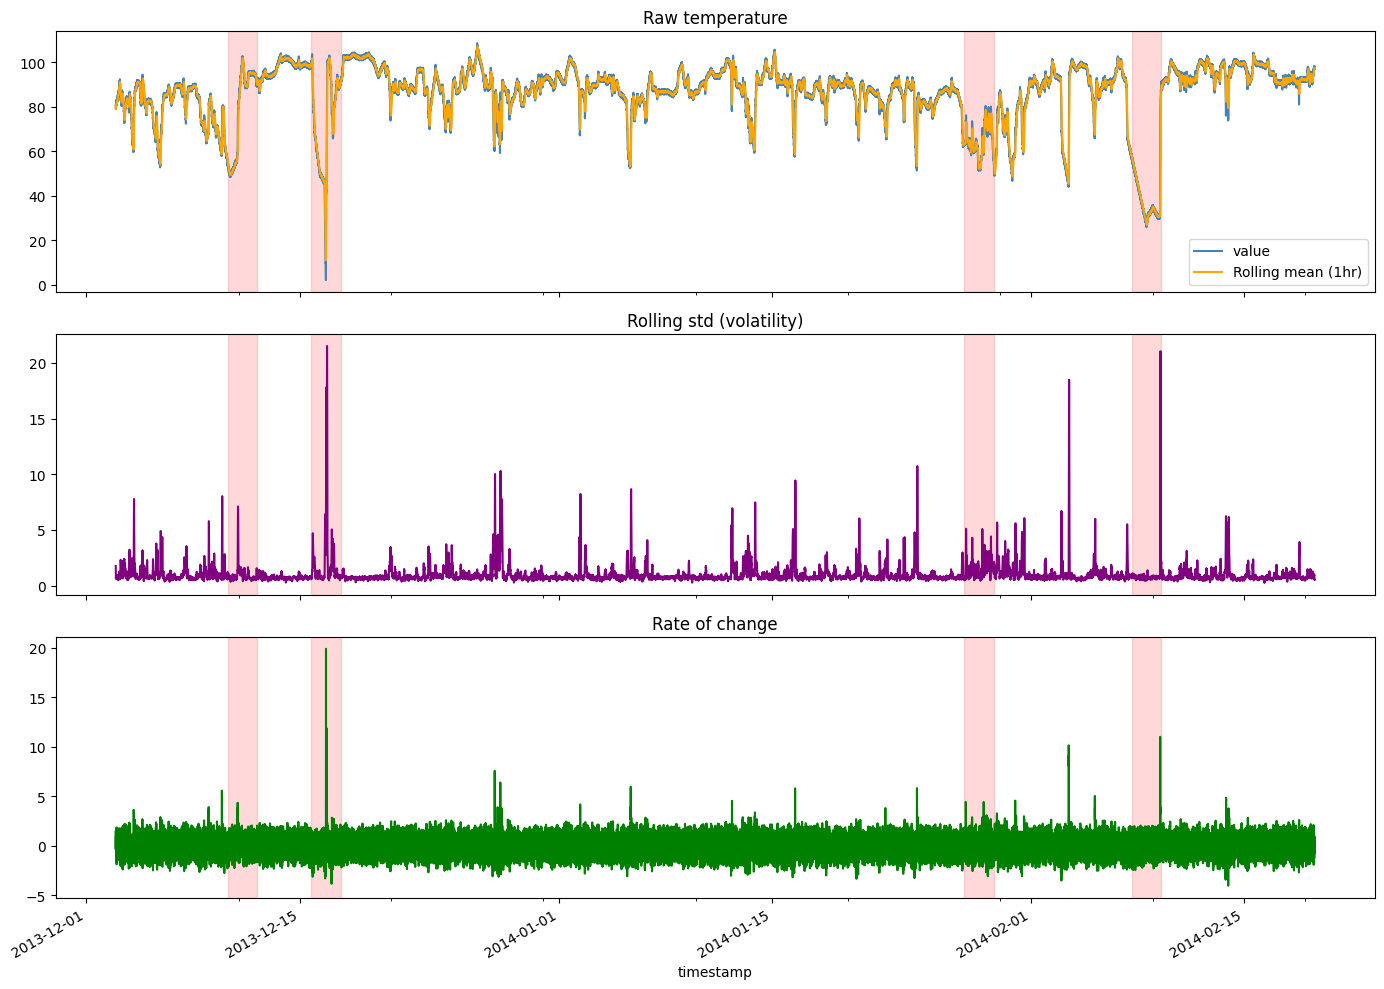

In [12]:
# ploitting the engineered features alongside the raw value
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

df['value'].plot(ax=axes[0], color='steelblue', title='Raw temperature')
df['rolling_mean'].plot(ax=axes[0], color='orange', label='Rolling mean (1hr)')
axes[0].legend()

df['rolling_std'].plot(ax=axes[1], color='purple', title='Rolling std (volatility)')

df['rate_of_change'].plot(ax=axes[2], color='green', title='Rate of change')

# shade windows for anomlies on all three plots
for window in labels[key]:
    for ax in axes:
        ax.axvspan(window[0], window[1], color='red', alpha=0.15)

plt.tight_layout()
plt.show()

In [13]:
# standardize features
from sklearn.preprocessing import StandardScaler

feature_cols = ['value', 'rolling_mean', 'rolling_std', 'lag_1', 'lag_12', 'rate_of_change']
X = df[feature_cols].copy()
y = df['is_anomaly'].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=df.index)

print("Features scaled. Mean per feature (should be ~0):")
print(X_scaled.mean().round(4))

Features scaled. Mean per feature (should be ~0):
value             0.0
rolling_mean      0.0
rolling_std       0.0
lag_1             0.0
lag_12           -0.0
rate_of_change    0.0
dtype: float64


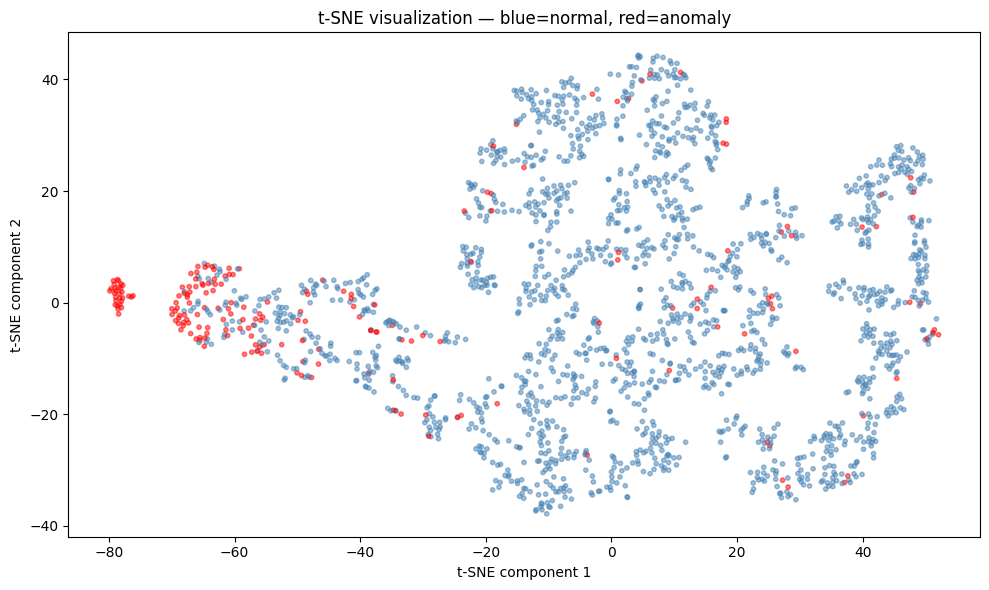

In [16]:
# t-SNE 
from sklearn.manifold import TSNE

sample_idx = df.sample(2000, random_state=42).index # sample of 2000 points to speed up
X_sample = X_scaled.loc[sample_idx]
y_sample = y.loc[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if label == 0 else 'red' for label in y_sample]
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.5, s=10)
plt.title('t-SNE visualization — blue=normal, red=anomaly')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.tight_layout()
plt.show()